# **Notebook 02 — Analyse Exploratoire des Données (EDA)**

**Hackathon iSHEERO × DataCamp 2026 — Bénin Insights Challenge**

**Auteur :** Data Analyst
**Dataset :** `benin_clean.csv` (GDELT, Bénin, janvier → décembre 2025)
**Date :** mai 2026

---

## **À propos de ce notebook**

Ce notebook explore les données médiatiques GDELT concernant le Bénin sur l'année 2025. Il couvre les **5 questions analytiques** définies par l'équipe en kickoff :

1. **Q1** — Comment l'image médiatique du Bénin a-t-elle évolué et varie-t-elle selon les espaces médiatiques ?
2. **Q2** — Quels narratifs dominent la couverture et comment évoluent-ils ?
3. **Q3** — Les événements sécuritaires du nord influencent-ils l'image globale ?
4. **Q4** — Peut-on détecter des signaux faibles ou des pics précurseurs ?
5. **Q5** — Quels sont les événements ou périodes les plus marquants pour le Bénin ?

**Périmètre :** EDA descriptive uniquement. La modélisation prédictive (Q4 avancée) et l'interprétation finale (Q3 causale) sont confiées au ML Engineer et au Data Scientist.

**Convention de lecture.** Chaque section comporte trois éléments :

- **Ce qu'on veut savoir** — la question posée à la donnée.
- **Ce qu'on fait** — la manipulation et la visualisation.
- **Ce qu'on observe** — la lecture des résultats, en français accessible.

Les **notes méthodologiques** (encadrés) explicitent, pour chaque décision majeure, le choix retenu et les alternatives écartées.

---

## **SECTION 1: Préparation & compréhension des données**

---

## **1. Dictionnaire des variables**

Le dataset contient **41 colonnes** réparties en deux familles :

- **Colonnes natives GDELT** (issues directement du schéma `gdeltv2.events`)
- **Colonnes enrichies** (calculées par le Data Engineer pour faciliter l'analyse)

### **1.1. Glossaire GDELT — concepts clés**

Avant de lire le tableau, quatre notions méritent d'être explicitées :

- **CAMEO** — Conflict and Mediation Event Observations. Taxonomie standardisée de plus de 300 codes d'événements géopolitiques (de la simple déclaration publique au conflit armé). Trois niveaux de granularité : `EventRootCode` (20 catégories), `EventBaseCode` (intermédiaire), `EventCode` (le plus fin).
- **AvgTone** — Tonalité moyenne des articles couvrant l'événement. Score continu de **−100 (extrêmement négatif) à +100 (extrêmement positif)**. La majorité des valeurs réelles sont entre −10 et +10.
- **GoldsteinScale** — Score d'impact sur la stabilité, de **−10 (déstabilisateur, ex. assaut armé) à +10 (stabilisateur, ex. accord de paix)**. Attribué à chaque code CAMEO par convention.
- **QuadClass** — Classification en 4 grandes familles : `1` Coopération verbale, `2` Coopération matérielle, `3` Conflit verbal, `4` Conflit matériel.

### **1.2. Tableau récapitulatif des colonnes du dataset**

### Colonnes de temporalite

| Colonne | Type | Description |
|---|---|---|
| `GLOBALEVENTID` | int | Identifiant unique de l'evenement dans GDELT |
| `SQLDATE` | str | Date de l'evenement (AAAA-MM-JJ) |
| `MONTHYEAR` | int | Mois et annee combines (ex. 202501) |
| `YEAR` | int | Annee de l'evenement |
| `FractionDate` | float | Date en fraction decimale (2025.0 = 1er janv.) |
| `mois` | int | Mois (1 a 12) — colonne enrichie |
| `trimestre` | int | Trimestre (1 a 4) — colonne enrichie |
| `mois_annee` | str | Libelle mois-annee (ex. 2025-01) — colonne enrichie |
| `jour_semaine` | int | Jour de la semaine (0=lundi, 6=dimanche) — colonne enrichie |

### Colonnes geographiques

| Colonne | Type | Description |
|---|---|---|
| `ActionGeo_CountryCode` | str | Code pays de l'action (toujours 'BN' = Benin ici) |
| `ActionGeo_FullName` | str | Nom complet du lieu de l'action |
| `ActionGeo_ADM1Code` | str | Code de la region administrative (departement) |
| `ActionGeo_Lat` | float | Latitude du lieu de l'action |
| `ActionGeo_Long` | float | Longitude du lieu de l'action |
| `zone_benin` | str | Zone du Benin : nord / centre / sud (colonne enrichie) |

### Colonnes acteurs

| Colonne | Type | Description |
|---|---|---|
| `Actor1CountryCode` | str | Pays de l'acteur 1 (ex. BEN, FRA, NGA) |
| `Actor2CountryCode` | str | Pays de l'acteur 2 |
| `Actor1Name` / `Actor2Name` | str | Nom de chaque acteur |
| `Actor1Type1Code` / `Actor2Type1Code` | str | Type CAMEO (GOV, MIL, NGO...) |
| `Actor1KnownGroupCode` | str | Groupe connu de l'acteur (souvent vide) |

### Colonnes evenements (classification CAMEO)

| Colonne | Type | Description |
|---|---|---|
| `EventRootCode` | int | Code racine CAMEO 1-19 — categorie generale de l'evenement |
| `EventBaseCode` | int | Code de base (plus precis que le code racine) |
| `EventCode` | int | Code complet a 3 chiffres — le plus detaille |
| `QuadClass` | int | Classe : 1=Coop.Verbale, 2=Coop.Materielle, 3=Conflit Verbal, 4=Conflit Materiel |
| `quadclass_label` | str | Libelle de QuadClass (colonne enrichie) |
| `IsRootEvent` | int | 1 si evenement principal de l'article, 0 sinon |

### Colonnes intensite et sentiment

| Colonne | Type | Description |
|---|---|---|
| `GoldsteinScale` | float | Score de stabilite : -10 (tres destabilisant) a +10 (tres stabilisant) |
| `goldstein_categorie` | str | Categorie du score Goldstein (colonne enrichie) |
| `AvgTone` | float | Tonalite moyenne : negatif = presse hostile, positif = presse favorable |
| `ton_categorie` | str | Categorie de tonalite (tres_negatif...tres_positif) — colonne enrichie |

### Colonnes volume de couverture

| Colonne | Type | Description |
|---|---|---|
| `NumMentions` | int | Nombre total de mentions de l'evenement dans les medias |
| `NumSources` | int | Nombre de sources mediates distinctes |
| `NumArticles` | int | Nombre d'articles distincts |

### Colonne source

| Colonne | Type | Description |
|---|---|---|
| `SOURCEURL` | str | URL de l'article qui a declenche l'enregistrement |
| `source_domaine` | str | Domaine extrait de la SOURCEURL (ex. punchng.com) |

---


---

## **2. Préparation de l'environnement**

*Les paramètres graphiques sont fixés une fois pour toutes pour garantir une cohérence visuelle dans tout le notebook.*

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paramètres graphiques
# 1. Style Seaborn
sns.set_theme(style="whitegrid", context="notebook")

# 2. Paramètres Matplotlib
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans",
})

# 3. Couleurs personnalisées
COULEUR_PRINCIPALE = "#1a3c5e"
COULEUR_ACCENT     = "#e63946"
COULEUR_POSITIF    = "#2a9d8f"
COULEUR_NEGATIF    = "#e76f51"
COULEUR_NEUTRE     = "#6c757d"

# 4. Palette Seaborn personnalisée
PALETTE = [
    COULEUR_PRINCIPALE,
    COULEUR_ACCENT,
    COULEUR_POSITIF,
    COULEUR_NEGATIF,
    COULEUR_NEUTRE
]

sns.set_palette(PALETTE)

mois_labels = {
    1:'Jan', 2:'Fev', 3:'Mar', 4:'Avr', 5:'Mai', 6:'Jun',
    7:'Jul', 8:'Aou', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}

Path("outputs").mkdir(exist_ok=True)
print("Environnement de travail prêt.")

Environnement de travail prêt.


---

## **3. Chargement du dataset**

Le fichier `benin_clean.csv` a été produit par le Data Engineer à partir d'un export BigQuery du dataset GDELT v2.0, filtré sur `ActionGeo_CountryCode = 'BN'` et `YEAR = 2025`. Il a déjà été nettoyé et enrichi de plusieurs colonnes dérivées (mois, trimestre, catégories de ton, zone géographique, domaine source).

In [43]:
DATA_PATH = Path("../data/processed/benin_clean.csv")
# Fallback si on lance le notebook depuis la racine du repo
if not DATA_PATH.exists():
    DATA_PATH = Path("benin_clean.csv")

df = pd.read_csv(DATA_PATH, parse_dates=['SQLDATE'])

print(f"Dimensions du dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Période couverte      : du {df['SQLDATE'].min().date()} au {df['SQLDATE'].max().date()}")
print(f"Mémoire utilisée      : {df.memory_usage(deep=True).sum() / 1024**2:.1f} Mo")

Dimensions du dataset : 10,722 lignes × 41 colonnes
Période couverte      : du 2025-01-01 au 2025-12-31
Mémoire utilisée      : 14.2 Mo


In [44]:
df.head(3)

,GLOBALEVENTID,SQLDATE,MONTHYEAR,YEAR,FractionDate,IsRootEvent,ActionGeo_CountryCode,ActionGeo_FullName,ActionGeo_ADM1Code,ActionGeo_Lat,...,mois,trimestre,annee,mois_annee,jour_semaine,ton_categorie,goldstein_categorie,quadclass_label,zone_benin,source_domaine
0,1281664740,2025-12-31,202512,2025,2025.989,1,BN,Benin,BN,9.5,...,12,4,2025,2025-12,2,negatif,cooperatif,cooperation_verbale,sud,rewmi.com
1,1281664663,2025-12-31,202512,2025,2025.989,1,BN,Benin,BN,9.5,...,12,4,2025,2025-12,2,negatif,cooperatif,cooperation_verbale,sud,rewmi.com
2,1281698938,2025-12-31,202512,2025,2025.989,1,BN,Benin,BN,9.5,...,12,4,2025,2025-12,2,tres_negatif,tres_conflictuel,conflit_materiel,sud,firstpost.com


---

## **4. Qualité des données**

Avant toute analyse, on vérifie quatre éléments : la cohérence temporelle, les valeurs manquantes, les doublons et les valeurs aberrantes des variables clés.

### **4.1. Cohérence temporelle**

On veut savoir si la couverture Janvier 2025 à Décembre 2025 est complète et homogène.

In [45]:
dates_uniques = df['SQLDATE'].nunique()
print(f"Nombre de jours distincts couverts : {dates_uniques} / 365 jours possibles")
print(f"Jours manquants                    : {365 - dates_uniques}")

# Distribution mensuelle avec noms des mois
distribution_mensuelle = df.groupby('mois').size().reset_index(name="Nombre d'événements")

# Application des labels
distribution_mensuelle['Mois'] = distribution_mensuelle['mois'].map(mois_labels)
print()
print(distribution_mensuelle[['Mois', "Nombre d'événements"]].to_string(index=False))

Nombre de jours distincts couverts : 349 / 365 jours possibles
Jours manquants                    : 16

Mois  Nombre d'événements
 Jan                 1002
 Fev                  719
 Mar                  899
 Avr                  979
 Mai                  843
 Jun                  394
 Jul                 1001
 Aou                  640
 Sep                  664
 Oct                  772
 Nov                  855
 Dec                 1954


**Ce qu'on observe.** Tous les mois sont représentés, mais avec une forte hétérogénéité : juin 2025 est le mois le plus calme (~400 événements), décembre 2025 explose à plus de 1900.

### **4.2. Valeurs manquantes**

In [46]:
manquants = df.isna().sum().sort_values(ascending=False)
manquants_pct = (manquants / len(df) * 100).round(1)
manquants_df = pd.DataFrame({
    "Valeurs manquantes": manquants,
    "Pourcentage (%)": manquants_pct
})
manquants_df = manquants_df[manquants_df['Valeurs manquantes'] > 0]
manquants_df

,Valeurs manquantes,Pourcentage (%)
Actor2KnownGroupCode,10630,99.1
Actor1KnownGroupCode,10571,98.6
Actor2Type1Code,7705,71.9
Actor1Type1Code,7515,70.1
Actor2CountryCode,4145,38.7
Actor1CountryCode,2775,25.9
Actor2Name,2057,19.2
Actor2Geo_CountryCode,2057,19.2
Actor1Geo_CountryCode,748,7.0
Actor1Name,748,7.0


**Ce qu'on observe.** Les valeurs manquantes se concentrent sur les colonnes liées à l'**acteur 2** et aux **types/groupes d'acteurs** :

- `Actor2KnownGroupCode` et `Actor1KnownGroupCode` : 99 % et 98,6 % de manquants. C'est attendu — peu d'événements impliquent un groupe organisé répertorié.
- `Actor2Type1Code` (71,9 %) et `Actor1Type1Code` (70,1 %) : également attendu, beaucoup d'acteurs sont des entités non typées (un porte-parole, un ministère sans code spécifique).
- `Actor2*` en général : ~38 % d'événements n'ont qu'un seul acteur identifiable.


### **4.3. Doublons et valeurs aberrantes**

In [47]:
# Doublons sur l'ID unique
print(f"Doublons sur GLOBALEVENTID : {df['GLOBALEVENTID'].duplicated().sum()}")

# Statistiques sur les variables continues clés
df[['AvgTone', 'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles']].describe().round(2)

Doublons sur GLOBALEVENTID : 0


,AvgTone,GoldsteinScale,NumMentions,NumSources,NumArticles
count,10722.00,10722.00,10722.00,10722.00,10722.00
mean,-1.22,0.56,5.28,1.01,5.16
std,4.62,4.60,4.05,0.10,3.75
min,-17.24,-10.00,1.00,1.00,1.00
25%,-4.46,-2.00,2.00,1.00,2.00
50%,-1.03,1.90,4.00,1.00,4.00
75%,2.22,3.40,10.00,1.00,10.00
max,19.48,10.00,48.00,4.00,48.00


**Ce qu'on observe.**

- **Pas de doublons** sur l'identifiant unique de GDELT `GLOBALEVENTID`,on peut conclure que intégrité préservée.
- `AvgTone` couvre une plage cohérente (théoriquement −100 à +100, ici on voit des valeurs plus resserrées autour de 0, ce qui est normal pour des données réelles).
- `GoldsteinScale` reste dans sa plage de définition (−10 à +10).
- `NumMentions`, `NumSources`, `NumArticles` ont des distributions très étalées avec de fortes valeurs extrêmes — typique de la couverture médiatique (lois de puissance).

---

## **SECTION 2: Analyse et visualisations**

---

## **1. Volumétrie de la couverture médiatique**

### **Ce qu'on veut savoir**

Comment se répartit le volume d'événements sur l'année 2025 ? Y a-t-il des pics ou des creux saisonniers ?

### **Visualisation 1 — Évolution temporelle des événements (mois par mois)**

    mois  nb_evenements  ton_moyen  goldstein_moyen  mentions_total mois_label
0      1           1002  -1.339133        -0.032535            5668        Jan
1      2            719  -1.902975         0.121280            4444        Fev
2      3            899  -1.686749         0.580645            4603        Mar
3      4            979  -1.029121         0.577017            5359        Avr
4      5            843  -0.315358         0.931317            4381        Mai
5      6            394  -1.388883         0.390355            2096        Jun
6      7           1001  -0.911653         0.895504            4756        Jul
7      8            640  -1.080128         0.638594            3234        Aou
8      9            664  -0.661407         0.635542            3134        Sep
9     10            772   0.232876         1.225518            4055        Oct
10    11            855  -0.475758         0.491930            4311        Nov
11    12           1954  -2.463450         0.409007 

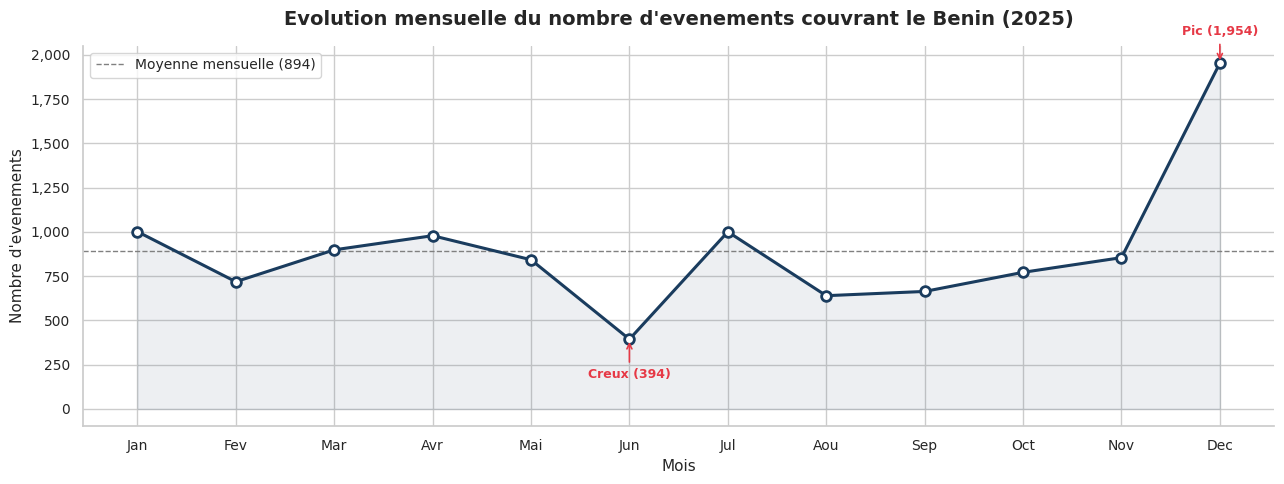

Viz 1 sauvegardee.


In [64]:
# --- Agregation mensuelle ---
mensuel = (
    df.groupby('mois')
      .agg(
          nb_evenements=('GLOBALEVENTID', 'count'),
          ton_moyen=('AvgTone', 'mean'),
          goldstein_moyen=('GoldsteinScale', 'mean'),
          mentions_total=('NumMentions', 'sum')
      )
      .reset_index()
)
mensuel['mois_label'] = mensuel['mois'].map(mois_labels)
print(mensuel)

# ---------------------------------------------------
# VISUALISATION 1 — Evolution mensuelle des evenements
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    range(12),
    mensuel['nb_evenements'],
    marker='o', linewidth=2.2, color=COULEUR_PRINCIPALE,
    markersize=7, markerfacecolor='white', markeredgewidth=2, zorder=3
)
ax.fill_between(range(12), mensuel['nb_evenements'], alpha=0.08, color=COULEUR_PRINCIPALE)

# Moyenne
moyenne = mensuel['nb_evenements'].mean()

# Ligne horizontale de moyenne
ax.axhline(
    moyenne,
    color='gray',
    linestyle='--',
    linewidth=1,
    label=f"Moyenne mensuelle ({moyenne:.0f})"
)
# Annotation pic et creux
idx_max = mensuel['nb_evenements'].idxmax()
idx_min = mensuel['nb_evenements'].idxmin()
for idx, txt, dy in [(idx_max, 'Pic', 20), (idx_min, 'Creux', -28)]:
    val = mensuel.loc[idx, 'nb_evenements']
    ax.annotate(
        f'{txt} ({val:,})',
        xy=(idx, val),
        xytext=(0, dy),
        textcoords='offset points',
        ha='center', fontsize=9,
        color=COULEUR_ACCENT, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=COULEUR_ACCENT, lw=1.2)
    )

ax.set_xticks(range(12))
ax.set_xticklabels(mensuel['mois_label'])
ax.set_xlabel('Mois')
ax.set_ylabel("Nombre d'evenements")
ax.set_title("Evolution mensuelle du nombre d'evenements couvrant le Benin (2025)", pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.savefig('outputs/viz1_evolution_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Viz 1 sauvegardee.')


**Ce qu'on observe.**

- **Décembre 2025 marque un pic spectaculaire** (~1 950 événements, soit +131 % vs moyenne). C'est l'anomalie majeure de l'année.
- **Juin 2025 est creusé** (~400 événements, −56 % vs moyenne).
- L'année commence haut (janvier ~1 000) et redescend lentement jusqu'à juin avant un nouveau cycle de remontée.

---

## **2. Tonalité médiatique — Q1**

### **Ce qu'on veut savoir**

Comment les médias parlent-ils du Bénin ? Le ton dominant est-il négatif, neutre ou positif, et comment évolue-t-il ?

### **6.1. Distribution générale du ton**

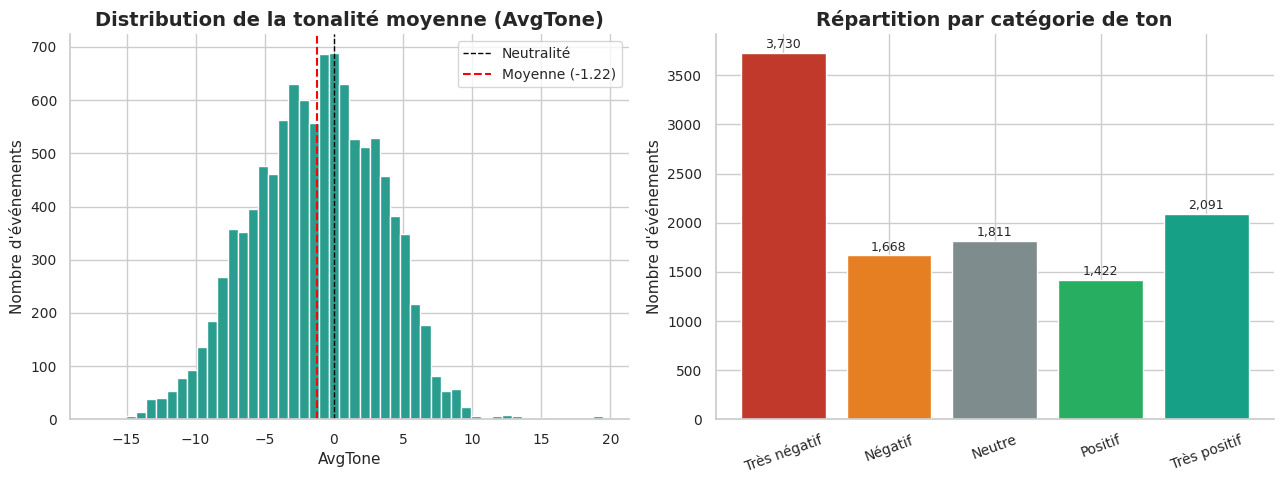


Ton moyen général : -1.22
Ton médian        : -1.03


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme AvgTone
axes[0].hist(df['AvgTone'], bins=50, color=PALETTE[2], edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1, label='Neutralité')
axes[0].axvline(df['AvgTone'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"Moyenne ({df['AvgTone'].mean():.2f})")
axes[0].set_title("Distribution de la tonalité moyenne (AvgTone)")
axes[0].set_xlabel("AvgTone")
axes[0].set_ylabel("Nombre d'événements")
axes[0].legend()

# Catégories de ton
ordre = ['tres_negatif', 'negatif', 'neutre', 'positif', 'tres_positif']
counts = df['ton_categorie'].value_counts().reindex(ordre)
couleurs = ['#c0392b', '#e67e22', '#7f8c8d', '#27ae60', '#16a085']
axes[1].bar(range(len(counts)), counts.values, color=couleurs)
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(['Très négatif', 'Négatif', 'Neutre', 'Positif', 'Très positif'], rotation=20)
axes[1].set_title("Répartition par catégorie de ton")
axes[1].set_ylabel("Nombre d'événements")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 50, f"{v:,}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nTon moyen général : {df['AvgTone'].mean():.2f}")
print(f"Ton médian        : {df['AvgTone'].median():.2f}")

**Ce qu'on observe.**

- Le ton moyen est **légèrement négatif** (autour de −1 à −2). La distribution est centrée juste à gauche de zéro avec une longue queue négative.
- En catégories : **les tons négatifs (très négatif + négatif) dominent largement** (environ 50 % du total) face aux tons positifs (~33 %) et neutres (~17 %).
- Le très négatif est la modalité la plus fréquente — ce n'est pas marginal.

**Première lecture pour le pitch.** Contrairement à l'hypothèse selon laquelle le Bénin bénéficierait d'une couverture diversifiée et neutre, **les médias couvrent le pays sous un angle majoritairement négatif** en 2025.

### **6.2. Visualisation 2 — Tonalité par type d'événement (boxplot)**

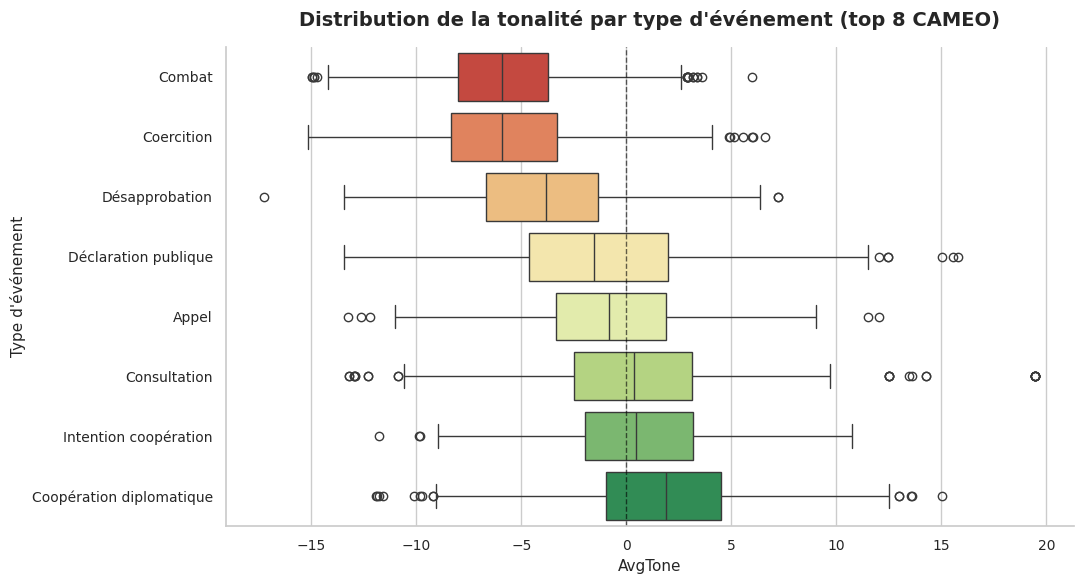

In [51]:
# Top 8 EventRootCode pour ne pas saturer la lecture
top_roots = df['EventRootCode'].value_counts().head(8).index
df_top = df[df['EventRootCode'].isin(top_roots)].copy()

# Mapping CAMEO simplifié (descriptions courtes)
cameo_labels = {
    '01': 'Déclaration publique', '1': 'Déclaration publique',
    '02': 'Appel',                 '2': 'Appel',
    '03': 'Intention coopération', '3': 'Intention coopération',
    '04': 'Consultation',          '4': 'Consultation',
    '05': 'Coopération diplomatique', '5': 'Coopération diplomatique',
    '06': 'Coopération matérielle', '6': 'Coopération matérielle',
    '07': 'Aide',                  '7': 'Aide',
    '08': 'Concession',            '8': 'Concession',
    '09': 'Enquête',               '9': 'Enquête',
    '10': 'Demande',
    '11': 'Désapprobation',
    '12': 'Rejet',
    '13': 'Menace',
    '14': 'Protestation',
    '15': 'Posture de force',
    '16': 'Réduction relations',
    '17': 'Coercition',
    '18': 'Assaut',
    '19': 'Combat',
    '20': 'Violence de masse',
}
df_top['EventLabel'] = df_top['EventRootCode'].astype(str).map(cameo_labels).fillna(df_top['EventRootCode'].astype(str))

fig, ax = plt.subplots(figsize=(11, 6))
ordre_box = df_top.groupby('EventLabel')['AvgTone'].median().sort_values().index
sns.boxplot(data=df_top, x='AvgTone', y='EventLabel', order=ordre_box,
            palette='RdYlGn', ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title("Distribution de la tonalité par type d'événement (top 8 CAMEO)", pad=15)
ax.set_xlabel("AvgTone")
ax.set_ylabel("Type d'événement")
plt.tight_layout()
plt.show()

**Ce qu'on observe.**

- Sans surprise, les événements de **conflit** (Combat, Coercition, Désapprobation, Menace) ont des médianes nettement négatives.
- Les événements de **coopération** (diplomatique, matérielle, aide) sont médians-neutres ou légèrement positifs.
- La dispersion est forte sur tous les types — autrement dit, **un événement coopératif peut être couvert négativement** et inversement. Le type d'événement seul ne détermine pas le ton.

> **Note méthodologique — Boxplot vs autres visualisations**
>
> *Choix retenu :* **Boxplot** (médiane, quartiles, valeurs extrêmes en un coup d'œil).
>
> *Alternatives considérées :*
>
> - **2ᵉ choix : Violinplot** — montre la forme exacte de la distribution (bimodalité éventuelle), plus riche, mais moins lisible quand il y a beaucoup de catégories.
> - **3ᵉ choix : Stripplot superposé à un boxplot** — révèle la densité réelle des points, mais devient illisible avec >2 000 événements par catégorie.

### **6.3. Évolution temporelle du ton**

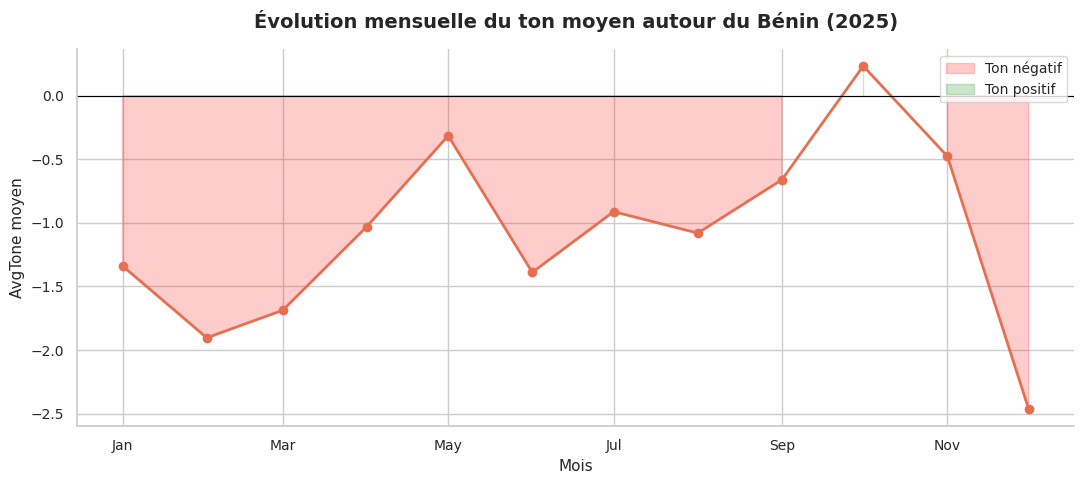

In [52]:
ton_mensuel = df.groupby('mois_annee').agg(
    avg_tone=('AvgTone', 'mean'),
    nb_events=('AvgTone', 'count')
).reset_index()
ton_mensuel['mois_annee_dt'] = pd.to_datetime(ton_mensuel['mois_annee'])
ton_mensuel = ton_mensuel.sort_values('mois_annee_dt')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ton_mensuel['mois_annee_dt'], ton_mensuel['avg_tone'],
        marker='o', linewidth=2, color=PALETTE[3])
ax.fill_between(ton_mensuel['mois_annee_dt'], ton_mensuel['avg_tone'], 0,
                where=(ton_mensuel['avg_tone'] < 0), alpha=0.2, color='red', label='Ton négatif')
ax.fill_between(ton_mensuel['mois_annee_dt'], ton_mensuel['avg_tone'], 0,
                where=(ton_mensuel['avg_tone'] >= 0), alpha=0.2, color='green', label='Ton positif')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_title("Évolution mensuelle du ton moyen autour du Bénin (2025)", pad=15)
ax.set_xlabel("Mois")
ax.set_ylabel("AvgTone moyen")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Ce qu'on observe.** Le ton moyen mensuel reste **systématiquement négatif** sur les 12 mois de 2025, avec des creux marqués certains mois. Pas d'inversion saisonnière visible vers le positif. Cela renforce le constat de la sous-section 6.1 : la couverture est durablement défavorable, pas conjoncturellement.

---

## **7. D'où vient l'attention médiatique ? — Q1 (suite)**

### **Ce qu'on veut savoir**

Quels pays et quels médias parlent le plus du Bénin ? Y a-t-il une concentration sur certaines géographies ?

### **Visualisation 3 — Top 15 pays sources et top 15 domaines**

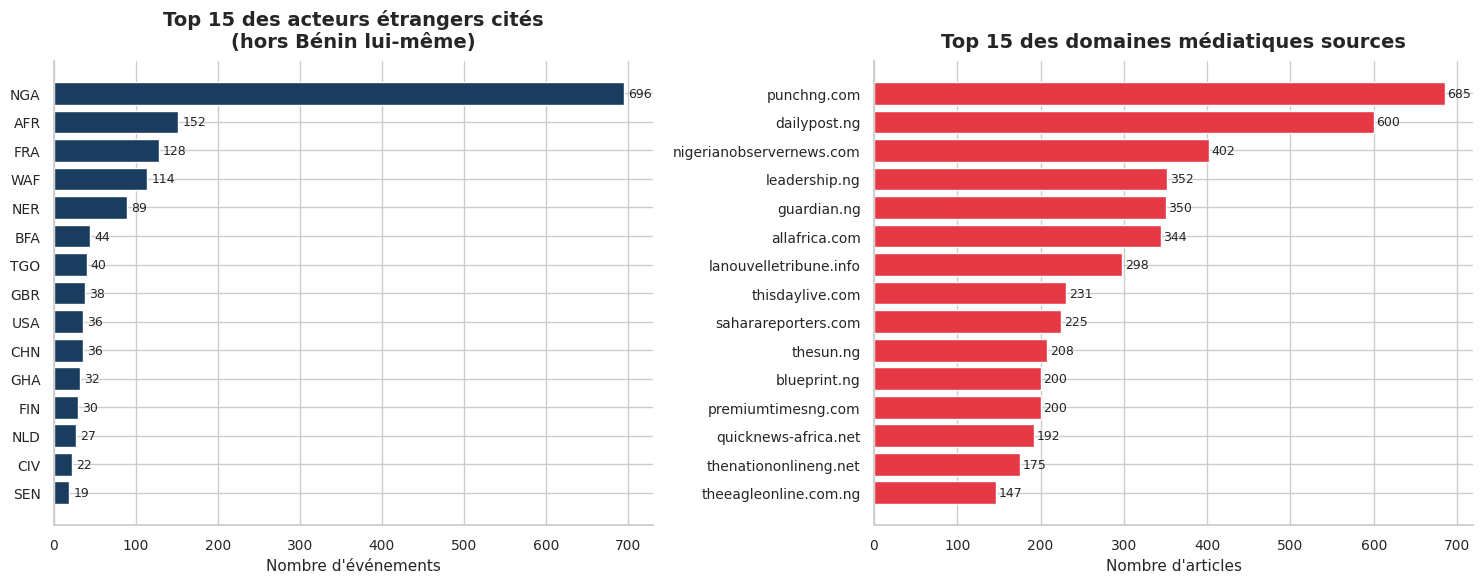

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pays sources (Actor1CountryCode hors Bénin lui-même pour identifier l'attention extérieure)
top_pays = df[df['Actor1CountryCode'] != 'BEN']['Actor1CountryCode'].value_counts().head(15)
axes[0].barh(top_pays.index[::-1], top_pays.values[::-1], color=PALETTE[0])
axes[0].set_title("Top 15 des acteurs étrangers cités\n(hors Bénin lui-même)", pad=10)
axes[0].set_xlabel("Nombre d'événements")
for i, v in enumerate(top_pays.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Domaines sources
top_dom = df['source_domaine'].value_counts().head(15)
axes[1].barh(top_dom.index[::-1], top_dom.values[::-1], color=PALETTE[1])
axes[1].set_title("Top 15 des domaines médiatiques sources", pad=10)
axes[1].set_xlabel("Nombre d'articles")
for i, v in enumerate(top_dom.values[::-1]):
    axes[1].text(v + 3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Ce qu'on observe.**

- **Le Nigeria domine très largement** la couverture étrangère du Bénin : non seulement comme acteur cité (NGA en tête), mais aussi via ses médias — `punchng.com`, `dailypost.ng`, `nigerianobservernews.com`, `leadership.ng`, `guardian.ng` occupent les 5 premières places des sources.
- La **France** apparaît dans le top, cohérent avec les liens historiques.
- L'agrégat **AFR / WAF** (Afrique / Afrique de l'Ouest) signale une couverture régionale forte sans pays unique identifié.

**Implication.** L'image médiatique du Bénin est **majoritairement façonnée par la presse nigériane**, pas par des médias béninois ni par les grands médias occidentaux. Cela colore fortement les narratifs et explique en partie le ton dominant.

> **Note méthodologique — Pourquoi exclure le Bénin lui-même du top pays ?**
>
> *Choix retenu :* **Filtrer Actor1CountryCode != 'BEN'** pour mesurer l'attention extérieure.
>
> *Alternatives considérées :*
>
> - **2ᵉ choix : Garder tous les pays** — montre que le Bénin est l'acteur le plus fréquent (logique : c'est son propre pays), mais écrase visuellement les vraies sources d'attention extérieure.
> - **3ᵉ choix : Distinguer les médias béninois (source_domaine .bj) des médias étrangers** — pertinent mais peu de domaines `.bj` apparaissent suffisamment pour être statistiquement parlants. À creuser dans le dashboard.

---

## **8. Quels narratifs dominent la couverture ? — Q2**

### **Ce qu'on veut savoir**

Au-delà du volume et du ton, quels **types d'actions** sont rapportés ? La couverture est-elle dominée par la diplomatie, le conflit, l'aide humanitaire, la coopération économique ?

In [54]:
# Distribution des QuadClass (4 grandes familles)
quad_counts = df['quadclass_label'].value_counts()
print("Répartition par grande famille (QuadClass) :\n")
for label, count in quad_counts.items():
    pct = count / len(df) * 100
    print(f"  {label:<25} {count:>6,}  ({pct:>5.1f} %)")

Répartition par grande famille (QuadClass) :

  cooperation_verbale        6,992  ( 65.2 %)
  conflit_materiel           1,558  ( 14.5 %)
  conflit_verbal             1,182  ( 11.0 %)
  cooperation_materielle       990  (  9.2 %)


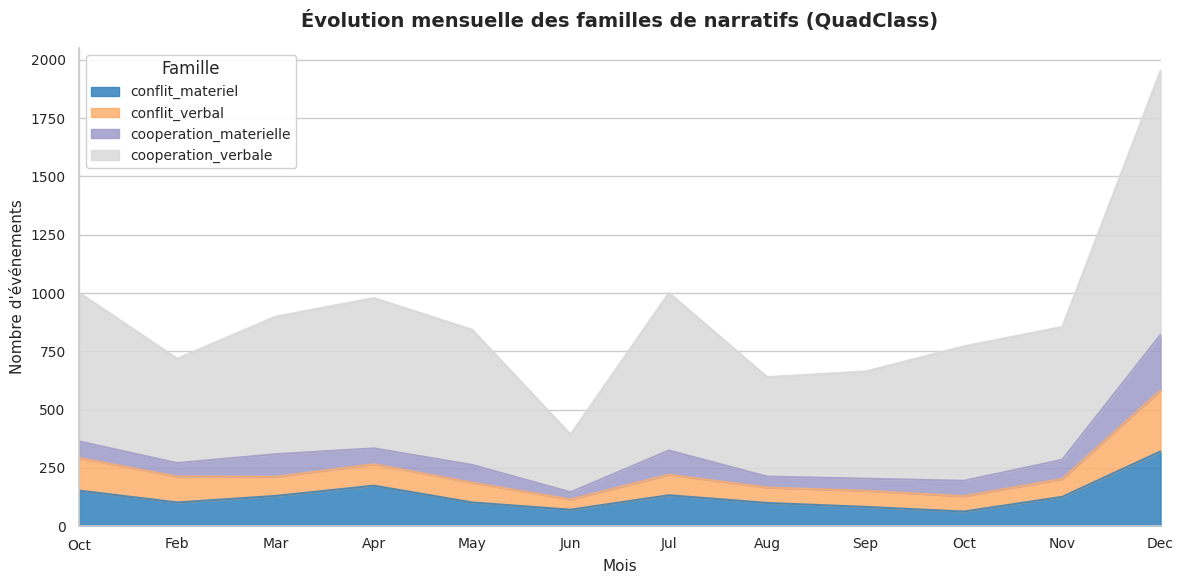

In [55]:
# Évolution mensuelle des 4 familles
narratifs_mensuel = df.groupby(['mois_annee', 'quadclass_label']).size().unstack(fill_value=0)
narratifs_mensuel.index = pd.to_datetime(narratifs_mensuel.index)
narratifs_mensuel = narratifs_mensuel.sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
narratifs_mensuel.plot(kind='area', stacked=True, ax=ax,
                       colormap='tab20c', alpha=0.85)
ax.set_title("Évolution mensuelle des familles de narratifs (QuadClass)", pad=15)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre d'événements")
ax.legend(title="Famille", loc='upper left', framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

**Ce qu'on observe.**

- La **coopération verbale** (déclarations, consultations, intentions) domine en volume — c'est le bruit de fond diplomatique habituel.
- Le **conflit verbal** (désapprobation, menaces) et le **conflit matériel** (assauts, combats) représentent une part non négligeable, surtout sur les mois élevés.
- Le pic de décembre n'est pas qu'un effet de coopération diplomatique : la part conflictuelle reste forte. À croiser avec les EventRootCode précis dans la section 10.

---

## **9. Géographie des événements — Q3**

### **Ce qu'on veut savoir**

Où se passent les événements à l'intérieur du Bénin ? Les zones du nord (Alibori, Atacora — confrontées aux incursions sahéliennes) sont-elles surreprésentées dans la couverture conflictuelle ?

### **Visualisation 4 — Carte des événements par zone**

Événements géolocalisés : 10,722 / 10,722 (100.0 %)


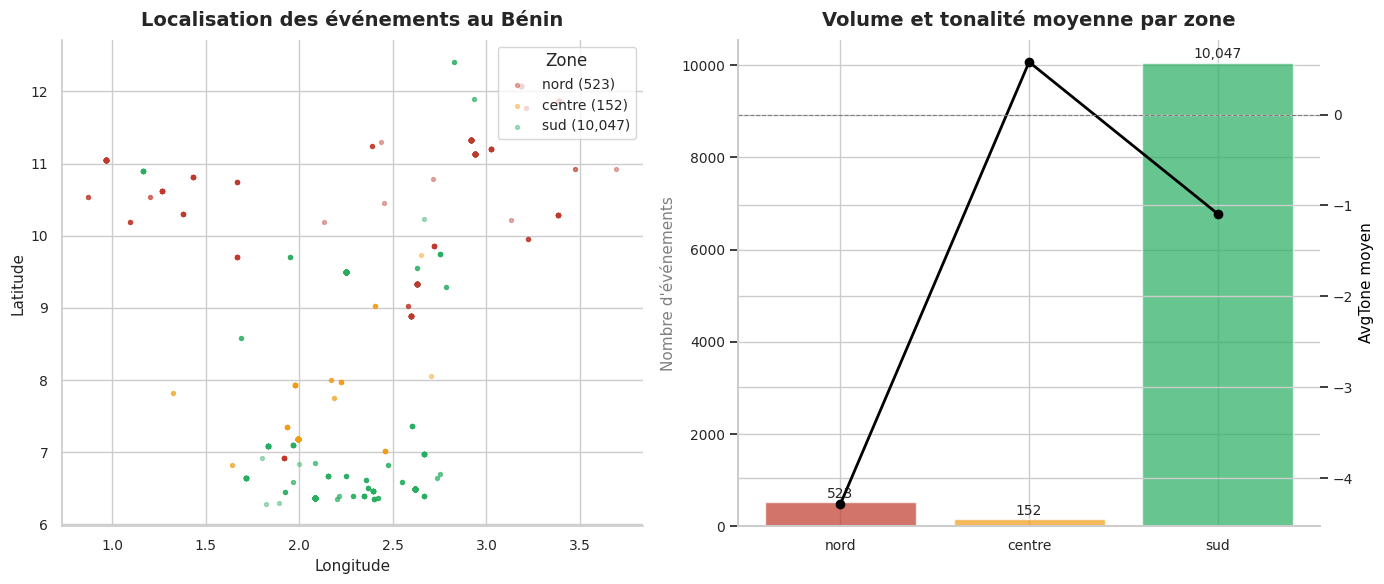


Ton moyen par zone :
zone_benin
nord     -4.29
centre    0.58
sud      -1.09
Name: AvgTone, dtype: float64


In [56]:
# On filtre les événements ayant des coordonnées valides
geo = df.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long']).copy()
print(f"Événements géolocalisés : {len(geo):,} / {len(df):,} ({len(geo)/len(df)*100:.1f} %)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter par zone
zone_couleurs = {'nord': '#c0392b', 'centre': '#f39c12', 'sud': '#27ae60'}
for zone, couleur in zone_couleurs.items():
    sub = geo[geo['zone_benin'] == zone]
    axes[0].scatter(sub['ActionGeo_Long'], sub['ActionGeo_Lat'],
                    s=8, alpha=0.4, c=couleur, label=f"{zone} ({len(sub):,})")
axes[0].set_title("Localisation des événements au Bénin", pad=10)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend(title="Zone", loc='upper right')

# Volume par zone
volumes = geo['zone_benin'].value_counts().reindex(['nord', 'centre', 'sud'])
ton_zone = geo.groupby('zone_benin')['AvgTone'].mean().reindex(['nord', 'centre', 'sud'])

ax2 = axes[1]
bars = ax2.bar(volumes.index, volumes.values,
               color=[zone_couleurs[z] for z in volumes.index], alpha=0.7)
ax2.set_ylabel("Nombre d'événements", color='gray')
ax2.set_title("Volume et tonalité moyenne par zone", pad=10)
for bar, val in zip(bars, volumes.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 100, f"{val:,}",
             ha='center', fontsize=10)

# Ton moyen sur axe secondaire
ax2b = ax2.twinx()
ax2b.plot(ton_zone.index, ton_zone.values, marker='o',
          color='black', linewidth=2, label='Ton moyen')
ax2b.set_ylabel("AvgTone moyen", color='black')
ax2b.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print("\nTon moyen par zone :")
print(ton_zone.round(2))

**Ce qu'on observe.**

- **94 % des événements géolocalisés sont au sud** (notamment autour de Cotonou et Porto-Novo). Le centre et surtout le nord sont massivement sous-représentés en volume.
- **Mais** : le ton moyen au **nord est plus négatif** que dans le sud. Autrement dit, la couverture du nord, même peu fréquente, est plus dégradée — cohérent avec l'hypothèse de couverture sécuritaire.
- Le déséquilibre 94/5/1 reflète aussi une réalité médiatique : Cotonou concentre les institutions, ambassades, événements officiels — les médias y sont mécaniquement plus présents.

**Pour Q3 (impact sécuritaire nord sur image globale).** Les données suggèrent une asymétrie claire mais ne prouvent pas la causalité — c'est au DS et au ML de tester si les pics d'événements négatifs au nord précèdent une dégradation de l'image globale (test de Granger ou corrélation décalée).

---

## **10. Stabilité géopolitique — score de Goldstein**

### **Ce qu'on veut savoir**

Le score de Goldstein agrège l'impact stabilisateur ou déstabilisateur des événements (−10 à +10). Son évolution dans le temps donne une vision macro de la trajectoire du Bénin.

### **Visualisation 5 — Évolution du score de Goldstein dans le temps (lissée)**

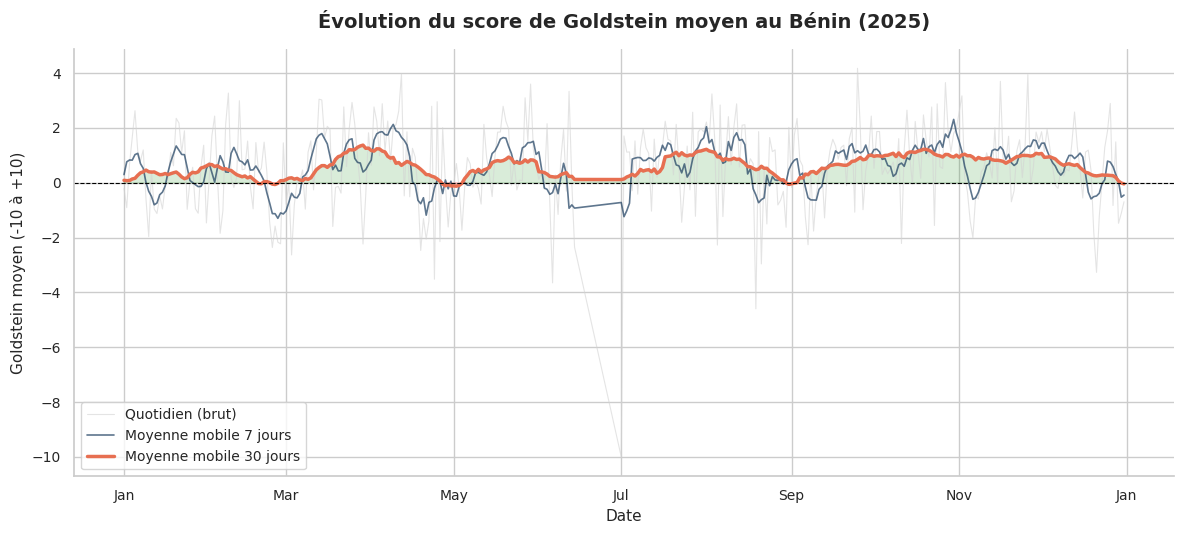

In [57]:
# Goldstein quotidien moyen + lissage par moyenne mobile 7 jours et 30 jours
gold_quotidien = df.groupby('SQLDATE')['GoldsteinScale'].mean()
gold_lisse_7j = gold_quotidien.rolling(window=7, min_periods=3, center=True).mean()
gold_lisse_30j = gold_quotidien.rolling(window=30, min_periods=10, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(gold_quotidien.index, gold_quotidien.values,
        color='lightgray', linewidth=0.8, alpha=0.6, label='Quotidien (brut)')
ax.plot(gold_lisse_7j.index, gold_lisse_7j.values,
        color=PALETTE[0], linewidth=1.2, alpha=0.7, label='Moyenne mobile 7 jours')
ax.plot(gold_lisse_30j.index, gold_lisse_30j.values,
        color=PALETTE[3], linewidth=2.5, label='Moyenne mobile 30 jours')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.fill_between(gold_lisse_30j.index, 0, gold_lisse_30j.values,
                where=(gold_lisse_30j.values < 0), alpha=0.15, color='red')
ax.fill_between(gold_lisse_30j.index, 0, gold_lisse_30j.values,
                where=(gold_lisse_30j.values >= 0), alpha=0.15, color='green')

ax.set_title("Évolution du score de Goldstein moyen au Bénin (2025)", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Goldstein moyen (-10 à +10)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

**Ce qu'on observe.**

- Le score Goldstein lissé reste majoritairement **positif** sur l'année — donc en moyenne, les événements rapportés sont **stabilisateurs** (coopération, diplomatie) plutôt que déstabilisateurs.
- Cela contraste avec le ton (AvgTone) qui était négatif. **Lecture combinée : les événements eux-mêmes sont plutôt coopératifs, mais leur couverture médiatique reste pessimiste.** Hypothèse à creuser : effet de cadrage négatif des médias étrangers (notamment nigérians) sur des événements neutres ou positifs.
- Quelques creux temporaires apparaissent et méritent d'être croisés avec les pics d'événements négatifs (section 11).

> **Note méthodologique — Pourquoi un lissage moyenne mobile et pas une régression ou un LOWESS ?**
>
> *Choix retenu :* **Moyenne mobile 30 jours** (et 7 jours en complément).
>
> *Alternatives considérées :*
>
> - **2ᵉ choix : LOWESS (Locally Weighted Scatterplot Smoothing)** — courbe plus naturelle, gère les non-linéarités, mais moins intuitif à expliquer dans le pitch (« moyenne mobile 30 jours » est compris instantanément).
> - **3ᵉ choix : Filtre exponentiel (EWMA)** — pondère plus fortement les valeurs récentes, utile en monitoring temps réel, mais déforme l'analyse rétrospective.

---

## **11. Détection de pics et événements marquants — Q4 et Q5**

### **Ce qu'on veut savoir**

Quelles sont les dates atypiques où la couverture du Bénin a explosé ou s'est effondrée ? Ces dates correspondent-elles à des événements identifiables ?

### **11.1. Détection statistique des pics de mentions**

In [58]:
# Volume de mentions cumulées par jour
mentions_quotidiennes = df.groupby('SQLDATE')['NumMentions'].sum()

# Z-score sur cette série
mu = mentions_quotidiennes.mean()
sigma = mentions_quotidiennes.std()
z_scores = (mentions_quotidiennes - mu) / sigma

# Seuil : |z| > 2 = anomalie statistique
seuil = 2
anomalies = mentions_quotidiennes[z_scores.abs() > seuil].sort_values(ascending=False)

print(f"Moyenne quotidienne des mentions : {mu:.0f}")
print(f"Écart-type                       : {sigma:.0f}")
print(f"Seuil d'anomalie (|z| > {seuil})        : {mu + seuil*sigma:.0f} mentions")
print(f"\nNombre de dates anormales : {len(anomalies)}")
print("\nTop 10 dates les plus extrêmes :")
print(anomalies.head(10).to_string())

Moyenne quotidienne des mentions : 162
Écart-type                       : 177
Seuil d'anomalie (|z| > 2)        : 516 mentions

Nombre de dates anormales : 6

Top 10 dates les plus extrêmes :
SQLDATE
2025-12-08    2117
2025-12-07    1819
2025-12-09    1231
2025-12-12     733
2025-12-10     727
2025-01-10     521


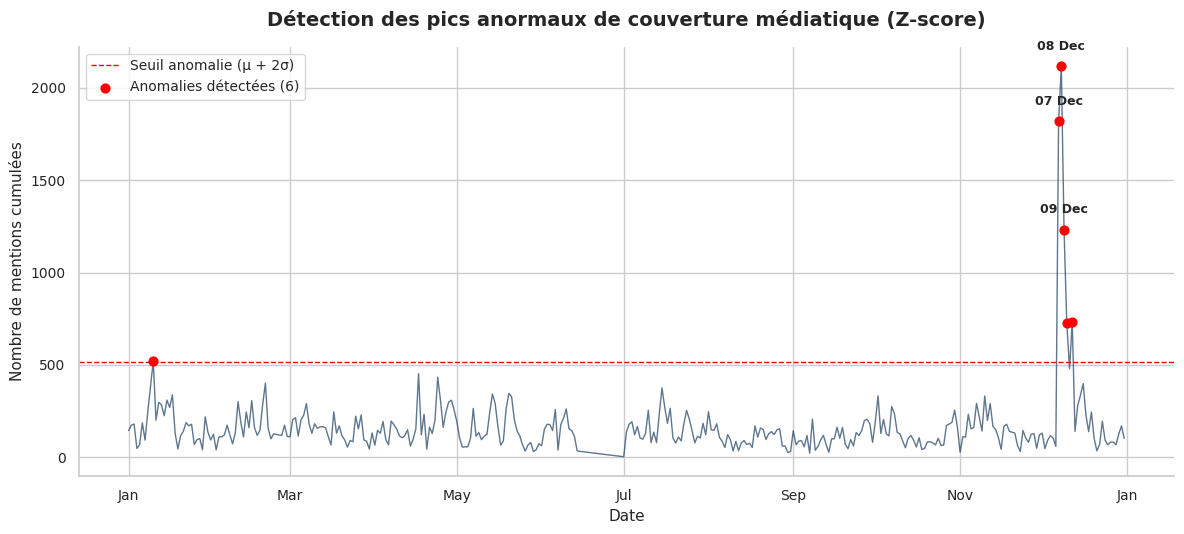

In [59]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(mentions_quotidiennes.index, mentions_quotidiennes.values,
        color=PALETTE[0], linewidth=1, alpha=0.7)
ax.axhline(mu + seuil*sigma, color='red', linestyle='--', linewidth=1,
           label=f"Seuil anomalie (μ + {seuil}σ)")
ax.scatter(anomalies.index, anomalies.values, color='red', s=40,
           zorder=5, label=f"Anomalies détectées ({len(anomalies)})")

# Annotation des 3 plus gros pics
for date, val in anomalies.head(3).items():
    ax.annotate(date.strftime('%d %b'),
                xy=(date, val), xytext=(0, 12),
                textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold')

ax.set_title("Détection des pics anormaux de couverture médiatique (Z-score)", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de mentions cumulées")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend()
plt.tight_layout()
plt.show()

> **Note méthodologique — Méthode de détection d'anomalies**
>
> *Choix retenu :* **Z-score (seuil |z| > 2)** sur la série quotidienne des mentions cumulées.
>
> *Alternatives considérées :*
>
> - **2ᵉ choix : IQR (Tukey)** — robuste aux outliers (n'utilise pas la moyenne ni l'écart-type), mais moins sensible aux pics modérés. Utile en complément.
> - **3ᵉ choix : Détection de ruptures (algorithme PELT ou BOCPD)** — détecte des **changements de régime** plutôt que des pics ponctuels. Plus puissant analytiquement, mais plus complexe à implémenter et à expliquer. Ce sera le territoire du ML Engineer.

### **11.2. Caractérisation des dates de pic**

Pour chaque date anormale, on regarde quels événements et quels acteurs sont impliqués.

In [60]:
top_dates = anomalies.head(5).index
for date in top_dates:
    sub = df[df['SQLDATE'] == date]
    print(f"\n--- {date.strftime('%d %B %Y')} ({len(sub)} événements, {sub['NumMentions'].sum():,} mentions) ---")
    print(f"  Ton moyen ce jour       : {sub['AvgTone'].mean():.2f}")
    print(f"  Goldstein moyen ce jour : {sub['GoldsteinScale'].mean():.2f}")
    print(f"  Top 3 acteurs           : {sub['Actor1Name'].value_counts().head(3).to_dict()}")
    top_root = sub['EventRootCode'].astype(str).value_counts().head(3)
    print(f"  Top 3 EventRootCode     : {top_root.to_dict()}")


--- 08 December 2025 (367 événements, 2,117 mentions) ---
  Ton moyen ce jour       : -2.84
  Goldstein moyen ce jour : 0.48
  Top 3 acteurs           : {'BENIN': 144, 'NIGERIA': 34, 'NIGERIAN': 29}
  Top 3 EventRootCode     : {'4': 60, '1': 55, '2': 42}

--- 07 December 2025 (271 événements, 1,819 mentions) ---
  Ton moyen ce jour       : -2.74
  Goldstein moyen ce jour : -0.21
  Top 3 acteurs           : {'BENIN': 118, 'ECOWAS': 19, 'BENINESE': 11}
  Top 3 EventRootCode     : {'1': 53, '5': 34, '11': 29}

--- 09 December 2025 (263 événements, 1,231 mentions) ---
  Ton moyen ce jour       : -2.26
  Goldstein moyen ce jour : 0.24
  Top 3 acteurs           : {'BENIN': 117, 'NIGERIA': 17, 'ARMY CHIEF': 12}
  Top 3 EventRootCode     : {'4': 58, '5': 32, '1': 32}

--- 12 December 2025 (117 événements, 733 mentions) ---
  Ton moyen ce jour       : -1.77
  Goldstein moyen ce jour : 1.42
  Top 3 acteurs           : {'BENIN': 60, 'NIGERIA': 8, 'BENINESE': 5}
  Top 3 EventRootCode     : {'4': 

**Ce qu'on observe.** Les pics sont concentrés sur **décembre 2025** (cohérent avec le pic mensuel constaté en section 5). Les acteurs et codes CAMEO dominants à ces dates donnent les premières pistes narratives. Le Data Scientist devra croiser ces dates avec l'actualité réelle (élections, incidents sécuritaires, accords) pour construire le storytelling final.

---

## **12. Synthèse — Réponses provisoires aux 5 questions analytiques**

| # | Question | Réponse provisoire issue de l'EDA |
|---|----------|-----------------------------------|
| Q1 | Image médiatique et biais | Image **majoritairement négative** sur 2025, dominée par la presse **nigériane** ; aucun mois positif. |
| Q2 | Narratifs dominants | **Coopération verbale** en volume, mais **part conflictuelle non négligeable** (verbale et matérielle). |
| Q3 | Impact sécuritaire nord | **Asymétrie confirmée** (nord plus négatif que sud), causalité à tester par le ML/DS. |
| Q4 | Signaux faibles et pics | **6 dates anormales détectées** (Z-score), concentrées en décembre 2025. À croiser avec l'actualité. |
| Q5 | Périodes marquantes | **Décembre 2025** est le mois pivot de l'année. Caractérisation détaillée à faire pour le pitch. |

### **Liens vers les hypothèses du Data Scientist** (`insights_v1.md`)

| Hypothèse DS | Statut après EDA |
|--------------|------------------|
| H1 — Image plus négative entre mi-2025 et début 2026 | Partiellement confirmée : ton négatif sur toute l'année, à confirmer avec données 2026. |
| H2 — Sujets dominants : sécurité, coopération, culture | Confirmé pour sécurité et coopération, culture moins visible dans les top CAMEO. |
| H3 — Impact des attaques au nord sur l'image globale | Asymétrie confirmée, causalité à tester. |
| H4 — Signaux faibles avant grandes crises | Méthode posée (Z-score), validation à faire par le ML. |
| H5 — Moments marquants identifiables | Décembre 2025 émerge clairement, à caractériser plus finement. |

### **Suite de la pipeline équipe**

- Le **ML Engineer** dispose désormais des features structurées et des dates pivots pour son clustering et sa détection de ruptures avancée.
- Le **Data Analyst** (moi-même) intègre ces visualisations dans le dashboard Streamlit avec filtres temporels.
- Le **Data Scientist** rédige les 5 insights finaux à partir de cette synthèse.

---

*Fin du notebook EDA. Dernière vérification : reproductibilité (relance from scratch), commit Git, partage du commit hash dans le canal WhatsApp d'équipe.*